# Experiment 7
## Comparison of various Learning Strategies for an MLP Classifier

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Algorithms for Intelligent Systems and Robotics Lab

### Aim
To compare various learning strategies for a Multi Layer Perceptron classifier, that is the solver, the learning rate, the learning rate schedule, the momentum, the activation function, the network architecture, the batch size and the regularisation, and to find which combination gives the best result on a real dataset.

### Theory

A **Multi Layer Perceptron** is a feed forward neural network having an input layer, one or more hidden layers and an output layer. The weights are learnt by backpropagation, but *how* those weights are updated is decided by the learning strategy, and the same network can give very different accuracy depending on it.

**Solver.** This is the optimisation algorithm which updates the weights.
- **sgd** updates the weights using the gradient of a small batch. It is simple but slow and it can get stuck.
- **adam** keeps a running average of the gradient and of the squared gradient, so it adjusts the step size of every weight on its own. It usually works well without much tuning.
- **lbfgs** is a quasi Newton method which uses an approximation of the second derivative. It works on the full batch, so it is very fast for a small dataset but it needs a lot of memory for a big one.

**Learning rate.** The size of the step taken in the direction opposite to the gradient. If it is too small the training is very slow, and if it is too large the update jumps over the minimum and the loss starts oscillating.

**Learning rate schedule.** In sklearn the value can be kept `constant`, reduced slowly as `invscaling`, or reduced only when the loss stops improving which is `adaptive`.

**Momentum.** A part of the previous update is added to the current one, so the movement keeps its direction and passes through small local dips and flat regions faster. **Nesterov momentum** looks ahead before computing the gradient.

**Activation function.** `relu`, `tanh`, `logistic` or `identity`. The identity activation makes the network linear no matter how many layers it has, so it is useful only as a check.

**Batch size.** The number of samples used for one weight update. A small batch gives a noisy but frequent update, a large batch gives a smooth but slow one.

**Regularisation (alpha).** An L2 penalty added on the weights, it keeps the weights small and controls overfitting.

### 1. Dataset
The `digits` dataset of sklearn is used. It has 1797 images of handwritten digits of size 8x8, so 64 features, and 10 classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report

digits = load_digits()
X, y = digits.data, digits.target

print("samples  :", X.shape[0])
print("features :", X.shape[1], "(8 x 8 pixels)")
print("classes  :", np.unique(y))

samples  : 1797
features : 64 (8 x 8 pixels)
classes  : [0 1 2 3 4 5 6 7 8 9]


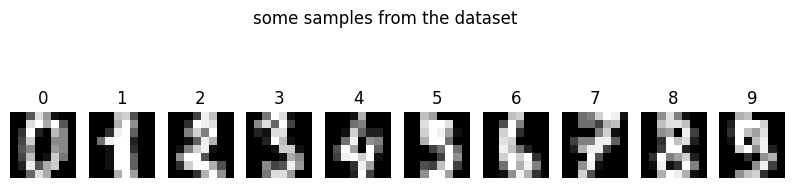

In [2]:
plt.figure(figsize=(10,2.4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(str(digits.target[i]))
    plt.axis('off')
plt.suptitle("some samples from the dataset", y=1.06)
plt.show()

The data is split into training and testing, and then standardised. Standardisation matters a lot for a neural network, if one feature has a much bigger range than the others then its weight receives a much bigger gradient and the training becomes unbalanced.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print("training samples :", X_train.shape[0])
print("testing samples  :", X_test.shape[0])
print("mean of the training data after scaling :", round(X_train.mean(), 6))
print("std of the training data after scaling  :", round(X_train.std(), 4))

training samples : 1347
testing samples  : 450
mean of the training data after scaling : 0.0
std of the training data after scaling  : 0.9763


A small helper is written so that every strategy can be trained and measured with the same code.

In [24]:
def run_mlp(name, **params):
    settings = dict(hidden_layer_sizes=(50,), max_iter=300, random_state=42)
    settings.update(params)

    start = time.time()
    model = MLPClassifier(**settings).fit(X_train, y_train)
    took = time.time() - start

    train_acc = model.score(X_train, y_train)
    test_acc  = model.score(X_test, y_test)

    return {"name": name, "model": model, "train": train_acc, "test": test_acc,
            "iters": model.n_iter_, "time": took}


def show_table(rows, title):
    print(title)
    print()
    print("strategy".ljust(20), "train".rjust(8), "test".rjust(8), "iters".rjust(7), "time(s)".rjust(9))
    print("-" * 56)
    for r in rows:
        print(r["name"].ljust(20), str(round(r["train"],4)).rjust(8), str(round(r["test"],4)).rjust(8),
              str(r["iters"]).rjust(7), str(round(r["time"],2)).rjust(9))

### 2. Strategy 1 : the solver
Seven settings are compared here, the three solvers and the different variants of sgd.

In [5]:
solver_settings = [
    ["adam",            dict(solver='adam', learning_rate_init=0.001)],
    ["sgd constant",    dict(solver='sgd', learning_rate='constant', learning_rate_init=0.01,
                             momentum=0, nesterovs_momentum=False)],
    ["sgd momentum",    dict(solver='sgd', learning_rate='constant', learning_rate_init=0.01,
                             momentum=0.9, nesterovs_momentum=False)],
    ["sgd nesterov",    dict(solver='sgd', learning_rate='constant', learning_rate_init=0.01,
                             momentum=0.9, nesterovs_momentum=True)],
    ["sgd invscaling",  dict(solver='sgd', learning_rate='invscaling', learning_rate_init=0.05,
                             momentum=0.9)],
    ["sgd adaptive",    dict(solver='sgd', learning_rate='adaptive', learning_rate_init=0.01,
                             momentum=0.9)],
    ["lbfgs",           dict(solver='lbfgs')],
]

solver_results = [run_mlp(name, **kw) for name, kw in solver_settings]
show_table(solver_results, "comparison of the solvers")

comparison of the solvers

strategy                train     test   iters   time(s)
--------------------------------------------------------
adam                      1.0   0.9711     180      0.25
sgd constant           0.9814   0.9511     300      0.38
sgd momentum              1.0   0.9689     197      0.25
sgd nesterov              1.0   0.9689     197      0.25
sgd invscaling          0.925   0.9089     300      0.39
sgd adaptive              1.0   0.9689     263      0.35
lbfgs                     1.0   0.9711      16      0.02


The loss curve of each one is plotted below. `lbfgs` is not in the plot because it is a full batch method and sklearn does not store a loss curve for it.

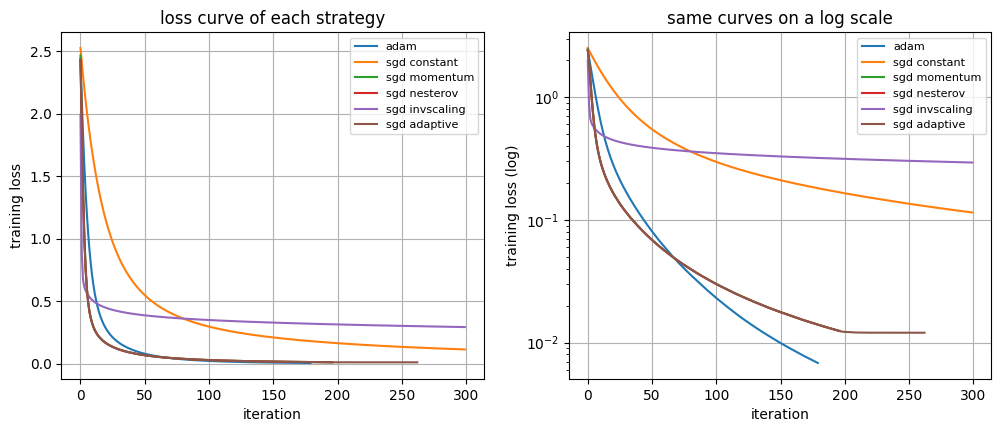

In [6]:
plt.figure(figsize=(12,4.5))

plt.subplot(1,2,1)
for r in solver_results:
    if hasattr(r["model"], "loss_curve_"):
        plt.plot(r["model"].loss_curve_, label=r["name"])
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("loss curve of each strategy")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,2,2)
for r in solver_results:
    if hasattr(r["model"], "loss_curve_"):
        plt.plot(r["model"].loss_curve_, label=r["name"])
plt.yscale("log")
plt.xlabel("iteration"); plt.ylabel("training loss (log)")
plt.title("same curves on a log scale")
plt.legend(fontsize=8); plt.grid(True)

plt.show()

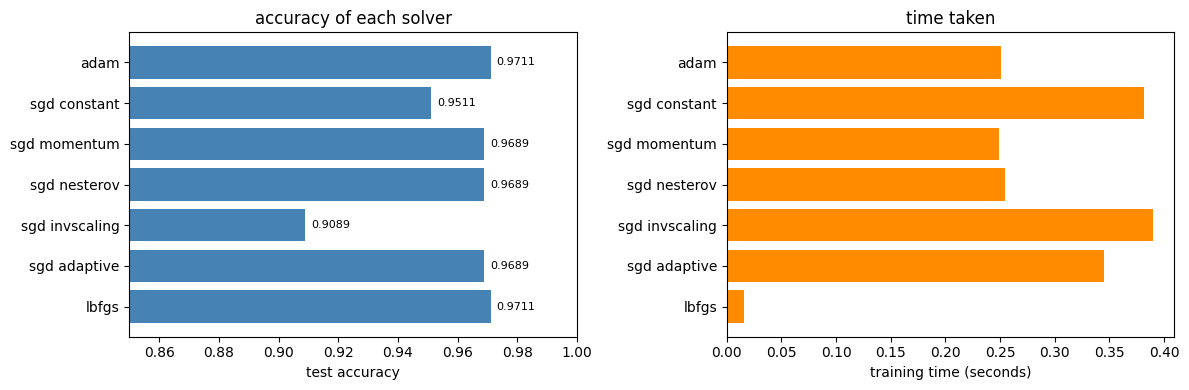

In [7]:
names = [r["name"] for r in solver_results]
test_accs = [r["test"] for r in solver_results]
times = [r["time"] for r in solver_results]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.barh(names[::-1], test_accs[::-1], color='steelblue')
plt.xlim(0.85, 1.0)
plt.xlabel("test accuracy"); plt.title("accuracy of each solver")
for i, v in enumerate(test_accs[::-1]):
    plt.text(v + 0.002, i, str(round(v,4)), va='center', fontsize=8)

plt.subplot(1,2,2)
plt.barh(names[::-1], times[::-1], color='darkorange')
plt.xlabel("training time (seconds)"); plt.title("time taken")

plt.tight_layout()
plt.show()

Three things come out of this comparison.

**lbfgs is the fastest by a big margin.** It finished in 16 iterations and 0.02 seconds and still reached the best test accuracy of 0.9711, the same as adam which needed 180 iterations. This happens because the dataset is small, only 1347 training samples, and lbfgs uses the full batch with second order information. On a large dataset it would not be usable because the memory needed grows with the number of weights.

**Momentum is what makes sgd usable.** Plain sgd with a constant rate stopped at 0.9511 after using all 300 iterations, and adding momentum of 0.9 took it to 0.9689 in 197 iterations. Nesterov momentum gave exactly the same numbers as normal momentum here, the look ahead correction is too small to matter on such a simple problem.

**invscaling was the worst at 0.9089.** In this schedule the learning rate keeps falling as the iterations go on, so it became too small before the network had finished learning, and the loss curve of that strategy is the one which flattens early and stays above the rest.

### 3. Strategy 2 : the learning rate
The learning rate is changed over five values keeping sgd with momentum, everything else is the same.

In [8]:
lr_results = []
for lr in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    r = run_mlp("lr = " + str(lr), solver='sgd', learning_rate_init=lr, momentum=0.9)
    r["lr"] = lr
    r["final_loss"] = r["model"].loss_
    lr_results.append(r)

show_table(lr_results, "effect of the learning rate")
print()
for r in lr_results:
    print(r["name"].ljust(12), "final training loss :", round(r["final_loss"], 4))

effect of the learning rate

strategy                train     test   iters   time(s)
--------------------------------------------------------
lr = 0.0001            0.8411     0.84     300      0.39
lr = 0.001             0.9814   0.9511     300      0.39
lr = 0.01                 1.0   0.9689     197      0.26
lr = 0.1                  1.0   0.9756      56      0.07
lr = 1.0               0.9659   0.9378      18      0.02

lr = 0.0001  final training loss : 0.8591
lr = 0.001   final training loss : 0.1153
lr = 0.01    final training loss : 0.0124
lr = 0.1     final training loss : 0.0029
lr = 1.0     final training loss : 0.189


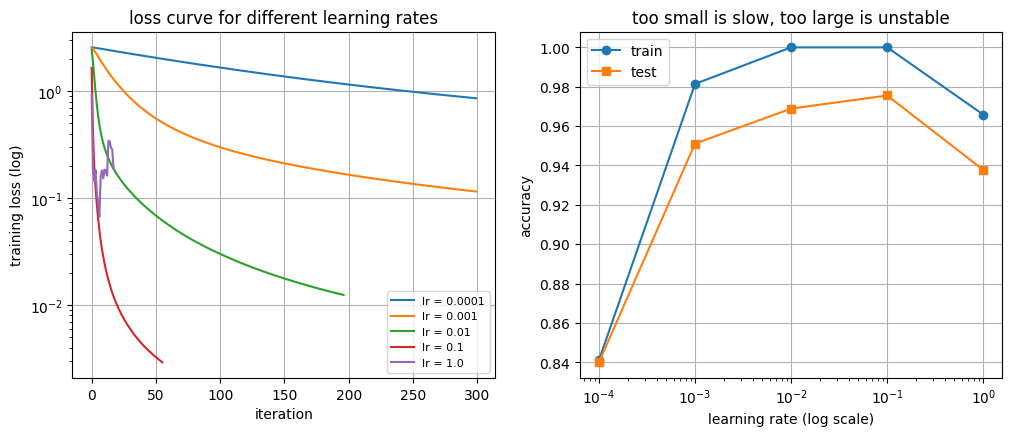

In [9]:
plt.figure(figsize=(12,4.5))

plt.subplot(1,2,1)
for r in lr_results:
    plt.plot(r["model"].loss_curve_, label=r["name"])
plt.yscale("log")
plt.xlabel("iteration"); plt.ylabel("training loss (log)")
plt.title("loss curve for different learning rates")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,2,2)
lrs = [r["lr"] for r in lr_results]
plt.semilogx(lrs, [r["train"] for r in lr_results], 'o-', label="train")
plt.semilogx(lrs, [r["test"] for r in lr_results], 's-', label="test")
plt.xlabel("learning rate (log scale)"); plt.ylabel("accuracy")
plt.title("too small is slow, too large is unstable")
plt.legend(); plt.grid(True)

plt.show()

This is the clearest result of the whole experiment. The accuracy against the learning rate makes a proper curve.

At 0.0001 the steps are so small that after 300 iterations the training loss is still 0.8591 and the accuracy is only 0.84, the network is simply not finished learning. At 0.1 the model reached the best test accuracy of 0.9756 and it needed only 56 iterations instead of 300. At 1.0 the accuracy fell back to 0.9378 and the final loss went up to 0.189, because the steps are now so large that the update jumps across the minimum, which can be seen as the jagged curve on the log plot.

So the learning rate is not something to be made as small as possible or as large as possible, there is a middle value which works best, and here it is 0.1 for sgd with momentum.

### 4. Strategy 3 : the activation function

In [10]:
act_results = [run_mlp(a, solver='adam', activation=a)
               for a in ['relu', 'tanh', 'logistic', 'identity']]
show_table(act_results, "effect of the activation function")

effect of the activation function

strategy                train     test   iters   time(s)
--------------------------------------------------------
relu                      1.0   0.9711     180      0.26
tanh                      1.0     0.98     213       0.3
logistic                  1.0   0.9733     300      0.48
identity                  1.0   0.9644     232      0.25


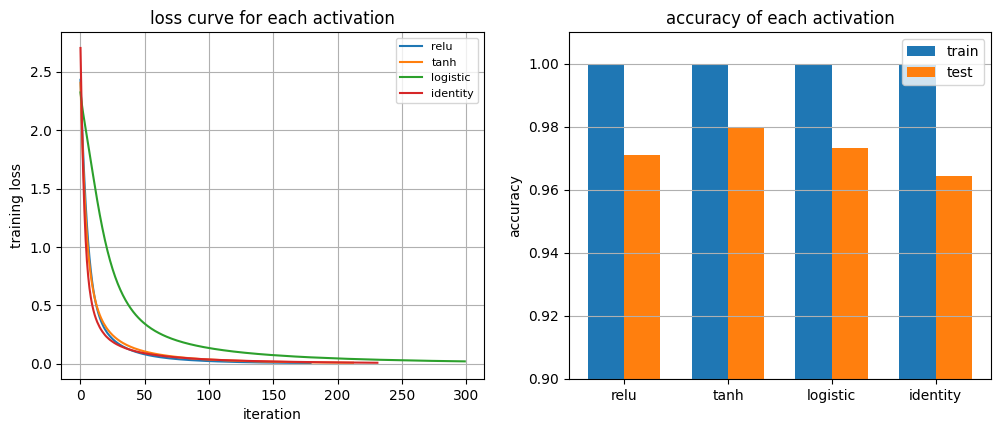

In [11]:
plt.figure(figsize=(12,4.5))

plt.subplot(1,2,1)
for r in act_results:
    plt.plot(r["model"].loss_curve_, label=r["name"])
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("loss curve for each activation")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,2,2)
x = np.arange(len(act_results)); w = 0.35
plt.bar(x - w/2, [r["train"] for r in act_results], w, label="train")
plt.bar(x + w/2, [r["test"] for r in act_results], w, label="test")
plt.xticks(x, [r["name"] for r in act_results])
plt.ylim(0.9, 1.01); plt.ylabel("accuracy")
plt.title("accuracy of each activation")
plt.legend(); plt.grid(axis='y')

plt.show()

`tanh` gave the best test accuracy of 0.98, a little better than `relu` at 0.9711. `logistic` reached 0.9733 but it used all the 300 iterations and took the longest time, which is the vanishing gradient problem, the sigmoid derivative becomes very small when the neuron saturates so the weights update slowly.

The interesting one is `identity`. With this activation the hidden layer does no bending at all and the whole network becomes one linear model, and yet it still reached 0.9644. This tells us something about the dataset rather than about the network, the digits data is very close to linearly separable after standardisation, so a non linear model wins only by about one and a half percent here.

### 5. Strategy 4 : the network architecture
Here the number of hidden layers and the number of neurons in them is changed.

In [12]:
arch_results = [run_mlp(str(h), solver='adam', hidden_layer_sizes=h)
                for h in [(10,), (50,), (100,), (50,50), (100,50,25)]]
show_table(arch_results, "effect of the architecture")

print()
for r, h in zip(arch_results, [(10,), (50,), (100,), (50,50), (100,50,25)]):
    total = 64*h[0] + h[0]
    for i in range(len(h)-1):
        total += h[i]*h[i+1] + h[i+1]
    total += h[-1]*10 + 10
    print(str(h).ljust(15), "has about", total, "parameters to learn")

effect of the architecture

strategy                train     test   iters   time(s)
--------------------------------------------------------
(10,)                  0.9963   0.9578     300      0.28
(50,)                     1.0   0.9711     180      0.26
(100,)                    1.0     0.98     147      0.28
(50, 50)                  1.0   0.9756     110      0.24
(100, 50, 25)             1.0   0.9778      74      0.25

(10,)           has about 760 parameters to learn
(50,)           has about 3760 parameters to learn
(100,)          has about 7510 parameters to learn
(50, 50)        has about 6310 parameters to learn
(100, 50, 25)   has about 13085 parameters to learn


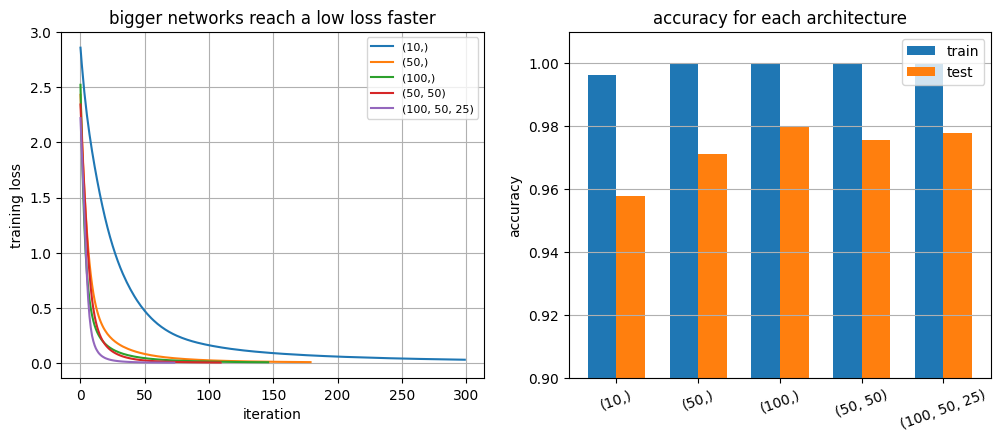

In [13]:
plt.figure(figsize=(12,4.5))

plt.subplot(1,2,1)
for r in arch_results:
    plt.plot(r["model"].loss_curve_, label=r["name"])
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("bigger networks reach a low loss faster")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,2,2)
x = np.arange(len(arch_results)); w = 0.35
plt.bar(x - w/2, [r["train"] for r in arch_results], w, label="train")
plt.bar(x + w/2, [r["test"] for r in arch_results], w, label="test")
plt.xticks(x, [r["name"] for r in arch_results], rotation=20)
plt.ylim(0.9, 1.01); plt.ylabel("accuracy")
plt.title("accuracy for each architecture")
plt.legend(); plt.grid(axis='y')

plt.show()

### 6. Strategy 5 : the batch size

In [14]:
batch_results = [run_mlp("batch " + str(b), solver='adam', batch_size=b)
                 for b in [8, 32, 128, 'auto']]
show_table(batch_results, "effect of the batch size")
print()
print("note : 'auto' means min(200, n_samples), so it is 200 here")

effect of the batch size

strategy                train     test   iters   time(s)
--------------------------------------------------------
batch 8                   1.0   0.9778      47      0.67
batch 32                  1.0   0.9733      84       0.4
batch 128                 1.0   0.9733     145      0.27
batch auto                1.0   0.9711     180      0.26

note : 'auto' means min(200, n_samples), so it is 200 here


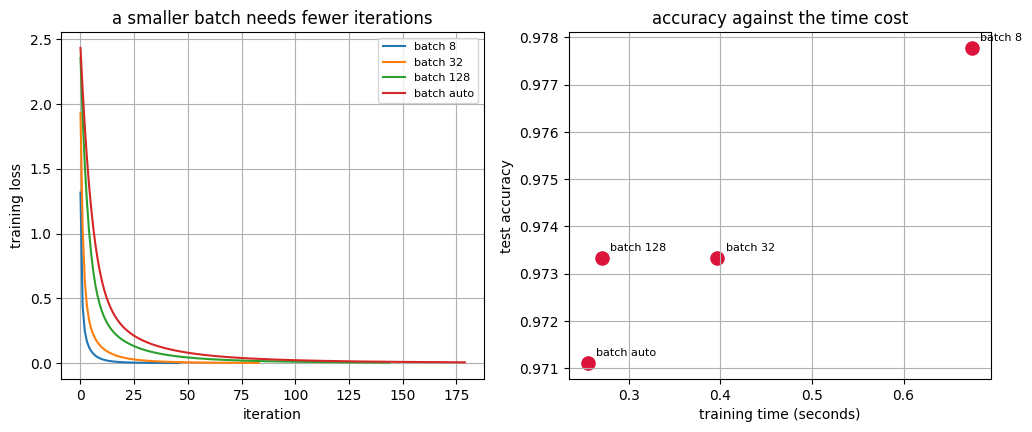

In [15]:
plt.figure(figsize=(12,4.5))

plt.subplot(1,2,1)
for r in batch_results:
    plt.plot(r["model"].loss_curve_, label=r["name"])
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("a smaller batch needs fewer iterations")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,2,2)
plt.scatter([r["time"] for r in batch_results], [r["test"] for r in batch_results], s=90, c='crimson')
for r in batch_results:
    plt.annotate(r["name"], (r["time"], r["test"]), textcoords="offset points", xytext=(6,5), fontsize=8)
plt.xlabel("training time (seconds)"); plt.ylabel("test accuracy")
plt.title("accuracy against the time cost")
plt.grid(True)

plt.show()

### 7. Strategy 6 : regularisation
Alpha is the L2 penalty on the weights. A very small value lets the network memorise the training data and a very large value stops it from learning at all.

In [16]:
alpha_values = [1e-6, 1e-4, 1e-2, 1.0, 10.0]
alpha_results = [run_mlp("alpha " + str(a), solver='adam', alpha=a) for a in alpha_values]
show_table(alpha_results, "effect of the regularisation")

effect of the regularisation

strategy                train     test   iters   time(s)
--------------------------------------------------------
alpha 1e-06               1.0   0.9711     180      0.26
alpha 0.0001              1.0   0.9711     180      0.26
alpha 0.01                1.0   0.9711     180      0.26
alpha 1.0              0.9993   0.9822     300      0.43
alpha 10.0             0.9673   0.9511     300      0.41


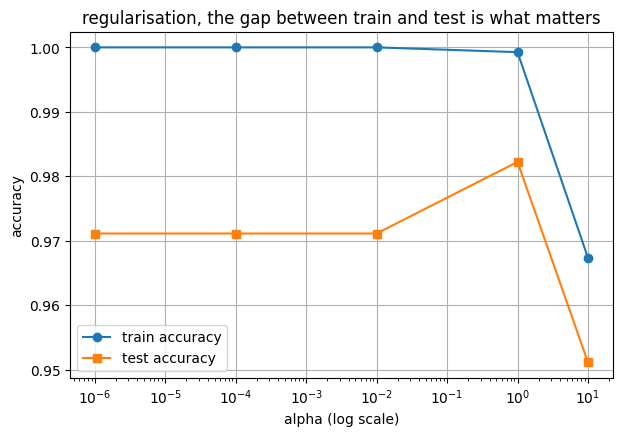

In [17]:
plt.figure(figsize=(7,4.5))
plt.semilogx(alpha_values, [r["train"] for r in alpha_results], 'o-', label="train accuracy")
plt.semilogx(alpha_values, [r["test"] for r in alpha_results], 's-', label="test accuracy")
plt.xlabel("alpha (log scale)"); plt.ylabel("accuracy")
plt.title("regularisation, the gap between train and test is what matters")
plt.legend(); plt.grid(True)
plt.show()

For alpha 1e-6, 1e-4 and 1e-2 nothing changes at all, the training accuracy stays at 1.0 and the test accuracy at 0.9711, these values are too small to have any effect on this network.

At alpha = 1.0 the training accuracy comes down slightly to 0.9993 but the test accuracy goes up to 0.9822, which is the best value seen so far in the whole experiment. This is exactly what regularisation is supposed to do, it stops the network from fitting the training data perfectly and that extra freedom is spent on generalising better.

At alpha = 10.0 the penalty becomes too strong, the weights are forced to stay so small that the network cannot fit even the training data, and both the accuracies fall to 0.9673 and 0.9511.

### 8. Putting the best settings together
The winners of the individual comparisons are combined into one model and it is compared with the default baseline.

In [18]:
baseline = run_mlp("baseline (default)", solver='adam')

tuned = run_mlp("tuned", hidden_layer_sizes=(100,), activation='tanh', solver='adam',
                alpha=1.0, learning_rate_init=0.001, max_iter=500)

show_table([baseline, tuned], "baseline against the tuned model")

wrong = (tuned["model"].predict(X_test) != y_test).sum()
print()
print("the tuned model got", wrong, "wrong out of", len(y_test), "test samples")

baseline against the tuned model

strategy                train     test   iters   time(s)
--------------------------------------------------------
baseline (default)        1.0   0.9711     180      0.26
tuned                  0.9993   0.9844     274       0.5

the tuned model got 7 wrong out of 450 test samples


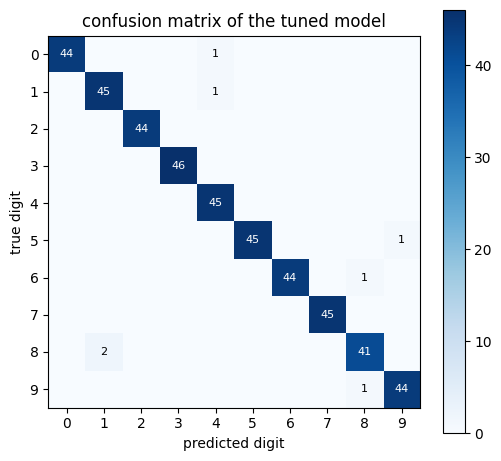

              precision    recall  f1-score   support

           0      1.000     0.978     0.989        45
           1      0.957     0.978     0.968        46
           2      1.000     1.000     1.000        44
           3      1.000     1.000     1.000        46
           4      0.957     1.000     0.978        45
           5      1.000     0.978     0.989        46
           6      1.000     0.978     0.989        45
           7      1.000     1.000     1.000        45
           8      0.953     0.953     0.953        43
           9      0.978     0.978     0.978        45

    accuracy                          0.984       450
   macro avg      0.985     0.984     0.984       450
weighted avg      0.985     0.984     0.984       450



In [19]:
y_pred = tuned["model"].predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5.5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            plt.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
plt.xlabel("predicted digit"); plt.ylabel("true digit")
plt.title("confusion matrix of the tuned model")
plt.xticks(range(10)); plt.yticks(range(10))
plt.show()

print(classification_report(y_test, y_pred, digits=3))

**The mistakes it made.** The seven wrong predictions are shown below as the actual images. The pixel values are brought back to the original scale using `inverse_transform` so that the digits can be seen properly.

In [ ]:
wrong_idx = np.where(y_pred != y_test)[0]
X_test_original = scaler.inverse_transform(X_test)

plt.figure(figsize=(11,2.6))
for j, idx in enumerate(wrong_idx):
    plt.subplot(1, len(wrong_idx), j+1)
    plt.imshow(X_test_original[idx].reshape(8,8), cmap='gray')
    plt.title("true " + str(y_test[idx]) + "\npredicted " + str(y_pred[idx]), fontsize=9)
    plt.axis('off')
plt.suptitle("all the digits the tuned model got wrong", y=1.12)
plt.show()

print("number of mistakes :", len(wrong_idx), "out of", len(y_test))
for idx in wrong_idx:
    print("   true", y_test[idx], "-> predicted", y_pred[idx])

Looking at the images explains most of the errors. These are 8x8 pictures, so a digit is drawn with only 64 pixels, and at that size an 8 with a thin loop really does look like a 1. A person would also hesitate on some of these.

**What the first layer learnt.** Every hidden neuron has 64 incoming weights, one for each pixel, so those weights can be reshaped back into an 8x8 image and displayed. A bright pixel means that neuron reacts strongly to ink at that position, and a dark pixel means the opposite.

In [ ]:
W1 = tuned["model"].coefs_[0]      # shape 64 x 100
print("shape of the first layer weights :", W1.shape)

plt.figure(figsize=(12,3.4))
for j in range(24):
    plt.subplot(3, 8, j+1)
    plt.imshow(W1[:, j].reshape(8,8), cmap='RdBu',
               vmin=-abs(W1).max()/2, vmax=abs(W1).max()/2)
    plt.axis('off')
plt.suptitle("weights of the first 24 hidden neurons, seen as 8x8 images", y=1.03)
plt.show()

print("red means the neuron is excited by ink there, blue means it is suppressed")
print("weight range :", round(W1.min(), 3), "to", round(W1.max(), 3))

None of these look like a full digit, and that is the expected result. A hidden neuron is not a digit detector, it is a small feature detector, it responds to a stroke in one corner or an edge in the middle. The output layer is the one which combines about a hundred of such small opinions into the final decision about which digit it is.

### 9. Checking with cross validation
A single train test split can be lucky. So the best few strategies are checked again with 5 fold cross validation on the whole dataset, where the scaling is put inside a pipeline so that the test fold is never used for computing the mean and the standard deviation.

In [20]:
from sklearn.pipeline import make_pipeline

cv_settings = [
    ["adam default",       dict(solver='adam')],
    ["sgd momentum 0.1",   dict(solver='sgd', learning_rate_init=0.1, momentum=0.9)],
    ["lbfgs",              dict(solver='lbfgs')],
    ["tuned",              dict(hidden_layer_sizes=(100,), activation='tanh',
                                solver='adam', alpha=1.0)],
]

cv_rows = []
for name, kw in cv_settings:
    settings = dict(hidden_layer_sizes=(50,), max_iter=300, random_state=42)
    settings.update(kw)
    pipe = make_pipeline(StandardScaler(), MLPClassifier(**settings))
    scores = cross_val_score(pipe, X, y, cv=5)
    cv_rows.append([name, scores.mean(), scores.std()])
    print(name.ljust(20), "mean", round(scores.mean(),4), " std", round(scores.std(),4),
          " folds", np.round(scores,3))

adam default         mean 0.9299  std 0.0201  folds [0.933 0.908 0.955 0.947 0.905]


sgd momentum 0.1     mean 0.9327  std 0.023  folds [0.942 0.908 0.953 0.958 0.903]
lbfgs                mean 0.9315  std 0.0221  folds [0.947 0.933 0.955 0.93  0.891]


tuned                mean 0.936  std 0.0294  folds [0.942 0.908 0.958 0.975 0.897]


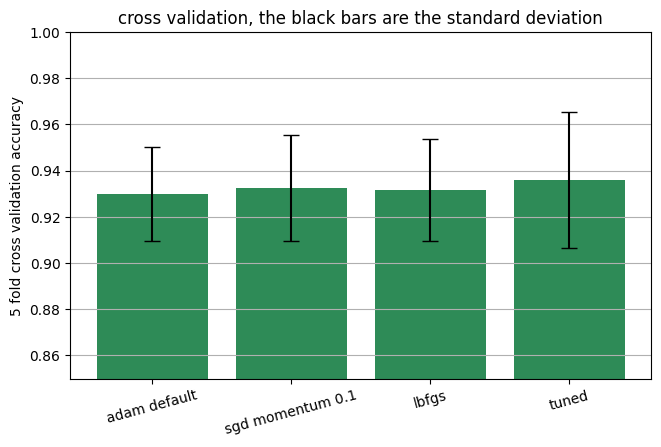

In [21]:
plt.figure(figsize=(7.5,4.5))
plt.bar([r[0] for r in cv_rows], [r[1] for r in cv_rows],
        yerr=[r[2] for r in cv_rows], capsize=6, color='seagreen')
plt.ylabel("5 fold cross validation accuracy")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=15)
plt.title("cross validation, the black bars are the standard deviation")
plt.grid(axis='y')
plt.show()

### 10. Result

All the learning strategies were compared on the digits dataset with 1347 training and 450 testing samples.

**Solvers**

| Strategy | Train | Test | Iterations | Time (s) |
|---|---|---|---|---|
| adam | 1.0000 | 0.9711 | 180 | 0.25 |
| sgd constant | 0.9814 | 0.9511 | 300 | 0.38 |
| sgd momentum | 1.0000 | 0.9689 | 197 | 0.25 |
| sgd nesterov | 1.0000 | 0.9689 | 197 | 0.25 |
| sgd invscaling | 0.9250 | 0.9089 | 300 | 0.39 |
| sgd adaptive | 1.0000 | 0.9689 | 263 | 0.35 |
| **lbfgs** | 1.0000 | **0.9711** | **16** | **0.02** |

**Learning rate (sgd with momentum)**

| Learning rate | Train | Test | Iterations | Final loss |
|---|---|---|---|---|
| 0.0001 | 0.8411 | 0.8400 | 300 | 0.8591 |
| 0.001 | 0.9814 | 0.9511 | 300 | 0.1153 |
| 0.01 | 1.0000 | 0.9689 | 197 | 0.0124 |
| **0.1** | 1.0000 | **0.9756** | 56 | 0.0029 |
| 1.0 | 0.9659 | 0.9378 | 18 | 0.1890 |

**Activation, architecture, batch size and regularisation**

| Setting | Best value | Test accuracy |
|---|---|---|
| Activation | tanh | 0.9800 |
| Architecture | (100,) | 0.9800 |
| Batch size | 8 | 0.9778 |
| Alpha | 1.0 | 0.9822 |

**Final model**

| Model | Train | Test | Wrong predictions |
|---|---|---|---|
| Baseline, default settings | 1.0000 | 0.9711 | 13 of 450 |
| Tuned, (100,) tanh adam alpha 1.0 | 0.9993 | **0.9844** | **7 of 450** |

**5 fold cross validation**

| Strategy | Mean | Std |
|---|---|---|
| adam default | 0.9299 | 0.0201 |
| sgd momentum 0.1 | 0.9327 | 0.0230 |
| lbfgs | 0.9315 | 0.0221 |
| tuned | 0.9360 | 0.0294 |

### 11. Conclusion

Eight different learning strategies for a Multi Layer Perceptron were compared on the same dataset, and the experiment shows that the settings of the training matter as much as the network itself. The same architecture moved between an accuracy of 0.84 and 0.9844 only by changing how it was trained.

Among the solvers, lbfgs was clearly the most efficient on this data, reaching the joint best accuracy of 0.9711 in 16 iterations and 0.02 seconds against 180 iterations for adam. This advantage belongs to the size of the problem and not to the algorithm being better in general, because lbfgs works on the full batch and stores an approximation of the curvature, which stops being practical when the dataset or the network becomes large. Among the stochastic methods, momentum was the single most useful addition, it lifted plain sgd from 0.9511 to 0.9689 and reduced the iterations from 300 to 197, while the invscaling schedule was actively harmful here since it reduced the learning rate faster than the network could learn.

The learning rate produced the strongest effect of all. At 0.0001 the network was still underfitted after 300 iterations with a loss of 0.8591, at 0.1 it reached the best accuracy in only 56 iterations, and at 1.0 the loss rose again to 0.189 because the steps became too large and started jumping over the minimum. This confirms that the learning rate has a middle range which works and that both extremes fail, for two completely different reasons.

Regularisation gave the best single improvement of the experiment. Increasing alpha to 1.0 reduced the training accuracy slightly from 1.0000 to 0.9993 but raised the testing accuracy from 0.9711 to 0.9822, and increasing it further to 10.0 destroyed the fit completely. The identity activation result is also worth noting, it reached 0.9644 even though such a network is mathematically only a linear model, which shows that the digits data is nearly linearly separable and that the non linearity is contributing only a small part of the final accuracy.

Combining the best individual settings gave a tuned model with a test accuracy of 0.9844, making only 7 mistakes out of 450 test samples against 13 for the default baseline. The confusion matrix shows that the seven remaining errors are spread across the classes rather than concentrated in one place. The only mistake which repeated is an 8 being read as a 1, which happened twice, and the others are single cases such as 5 read as 9, 6 read as 8 and 9 read as 8, all of which are digits that genuinely look similar in an 8x8 image.

One honest observation must be recorded. The cross validation accuracies are much lower than the single split accuracies, around 0.93 against 0.97, and the four strategies tested there differ by less than one standard deviation from each other. This means the ordering obtained from one train test split should not be trusted too strongly, the split used in this experiment happened to be an easy one, and a proper comparison of strategies needs repeated splits before declaring any of them the winner.

It is concluded that no single learning strategy is best for every problem. The solver should be chosen according to the size of the data, the learning rate needs to be tuned first because it has the largest effect, momentum should be used whenever sgd is used, and regularisation should be increased until the gap between the training and testing accuracy starts closing.